## Headline:
- Replace hidden zeros with NaN
- Impute missing values using KNNImputer
- Detect and cap outliers using IQR

## Load & Zeros

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from diasense.config import CLINICAL_FEATURES, ZERO_AS_MISSING, MODELS_DIR, FIGURES_DIR,OUTLIER_COLUMNS,PROCESSED_DATA_DIR
from diasense.data import load_raw_data
from diasense.preprocessing import (
    replace_hidden_zeros,
    impute_knn,
    detect_outliers_iqr,
    cap_outliers_iqr,
    save_artifact,
    scale_data
    
    
)

sns.set_theme(style="whitegrid", context="notebook")

# Load raw data
df_raw = load_raw_data()

# Replace hidden zeros with NaN
df_nan = replace_hidden_zeros(df_raw)

print("Missing values AFTER replacing hidden zeros:")
print(df_nan[ZERO_AS_MISSING].isna().sum())

Missing values AFTER replacing hidden zeros:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## KNN Imputation

In [3]:
df_imputed, knn_imputer = impute_knn(df_nan[CLINICAL_FEATURES], n_neighbors=5)
assert df_imputed.isna().sum().sum() == 0, "DONE"

# fix result values
df_imputed["Pregnancies"] = df_imputed["Pregnancies"].round().astype(int)
df_imputed["Age"] = df_imputed["Age"].round().astype(int)

# Save the fitted imputer for the inference pipeline
save_artifact(knn_imputer, MODELS_DIR / "knn_imputer.joblib")

display(df_imputed.describe().round(2))




,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.60,72.38,29.10,153.06,32.42,0.47,33.24
std,3.37,30.50,12.21,9.42,98.27,6.89,0.33,11.76
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00
25%,1.00,99.00,64.00,23.00,87.90,27.50,0.24,24.00
50%,3.00,117.00,72.00,29.00,132.90,32.09,0.37,29.00
75%,6.00,140.25,80.00,35.00,190.15,36.60,0.63,41.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00


Now that data is imputed, we detect outliers visually and statistically.


## Detect Outliers

In [4]:
outlier_mask = detect_outliers_iqr(df_imputed,CLINICAL_FEATURES)
print("Numbers of outliers:\n",outlier_mask.sum())

Numbers of outliers:
 Pregnancies                  4
Glucose                      0
BloodPressure               14
SkinThickness                6
Insulin                     33
BMI                          8
DiabetesPedigreeFunction    29
Age                          9
dtype: int64


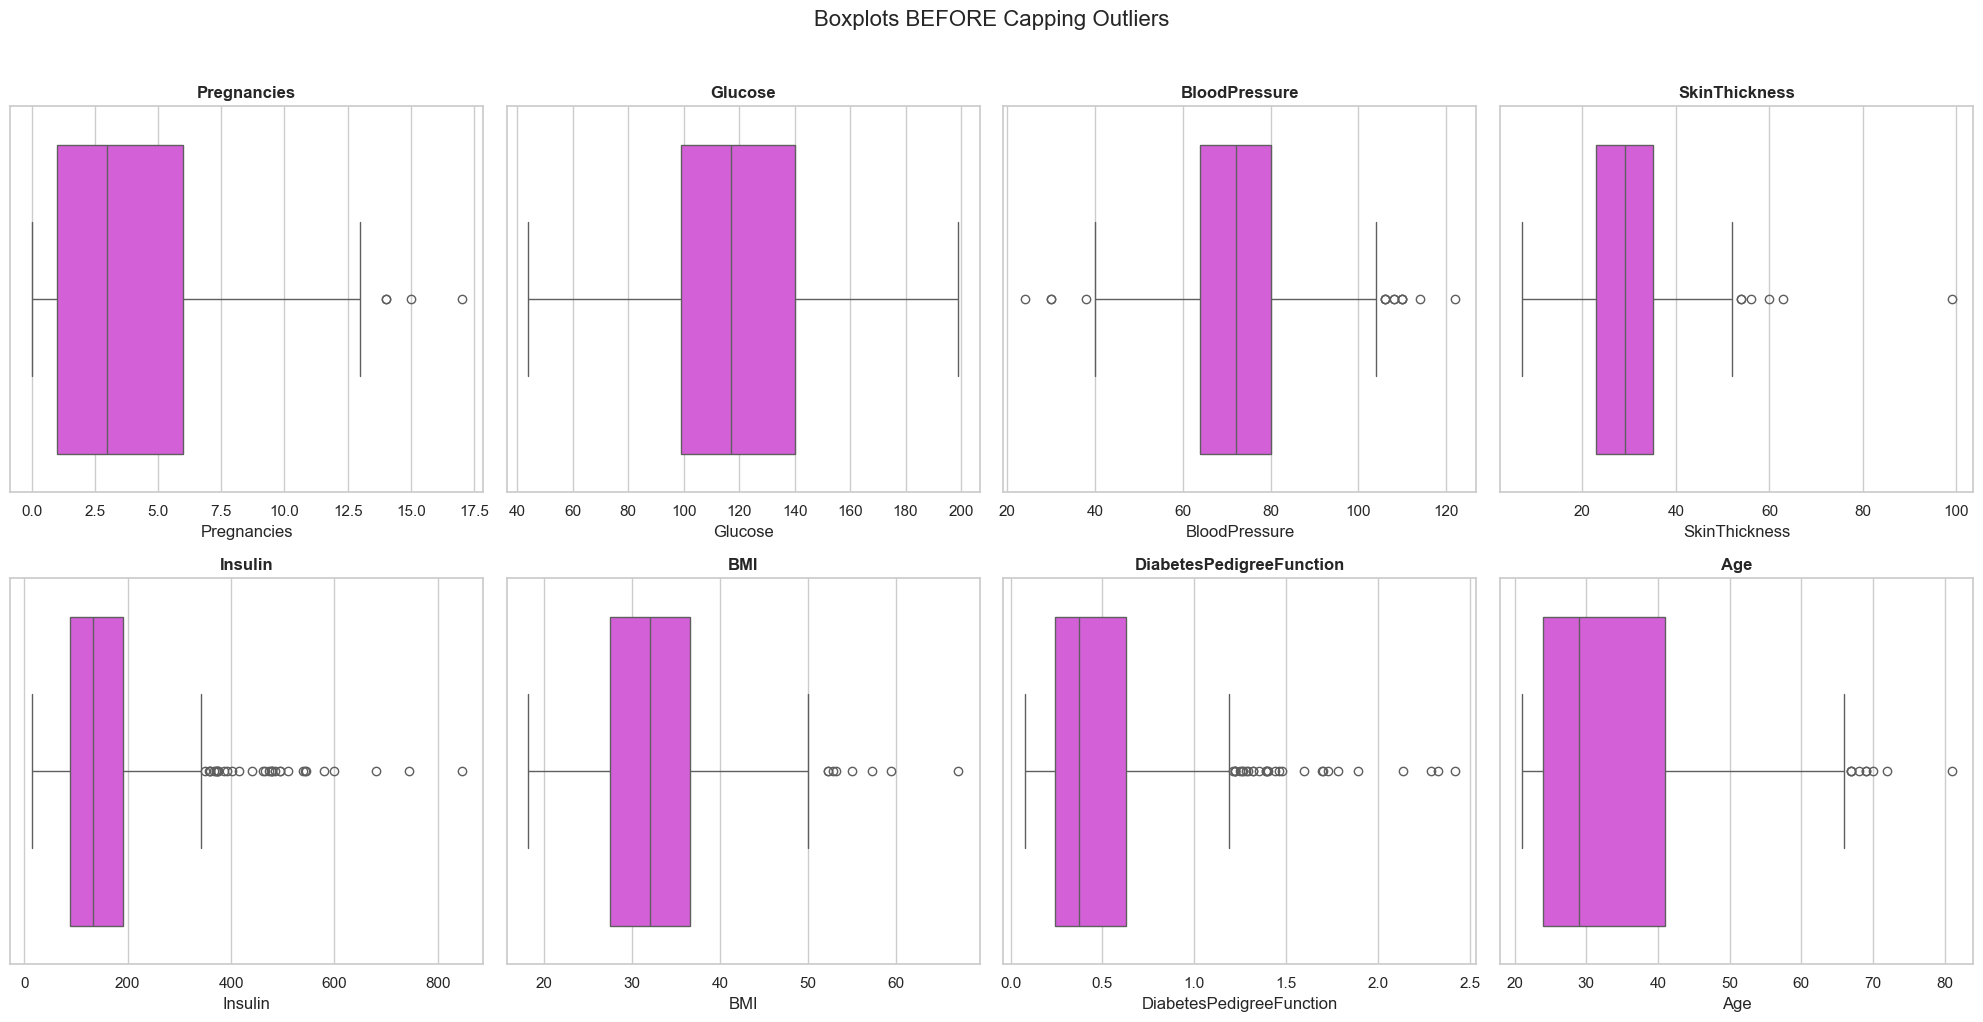

In [5]:
# Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i,col in enumerate(CLINICAL_FEATURES):
    sns.boxplot(x=df_imputed[col],ax=axes[i],color="#e74cec")
    axes[i].set_title(col,fontweight="bold")

plt.suptitle("Boxplots BEFORE Capping Outliers", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "preprocessing_boxplots_before_capping.png", dpi=150, bbox_inches="tight")
plt.show()

Instead of dropping rows (which loses data) | we cap values to the IQR limits.

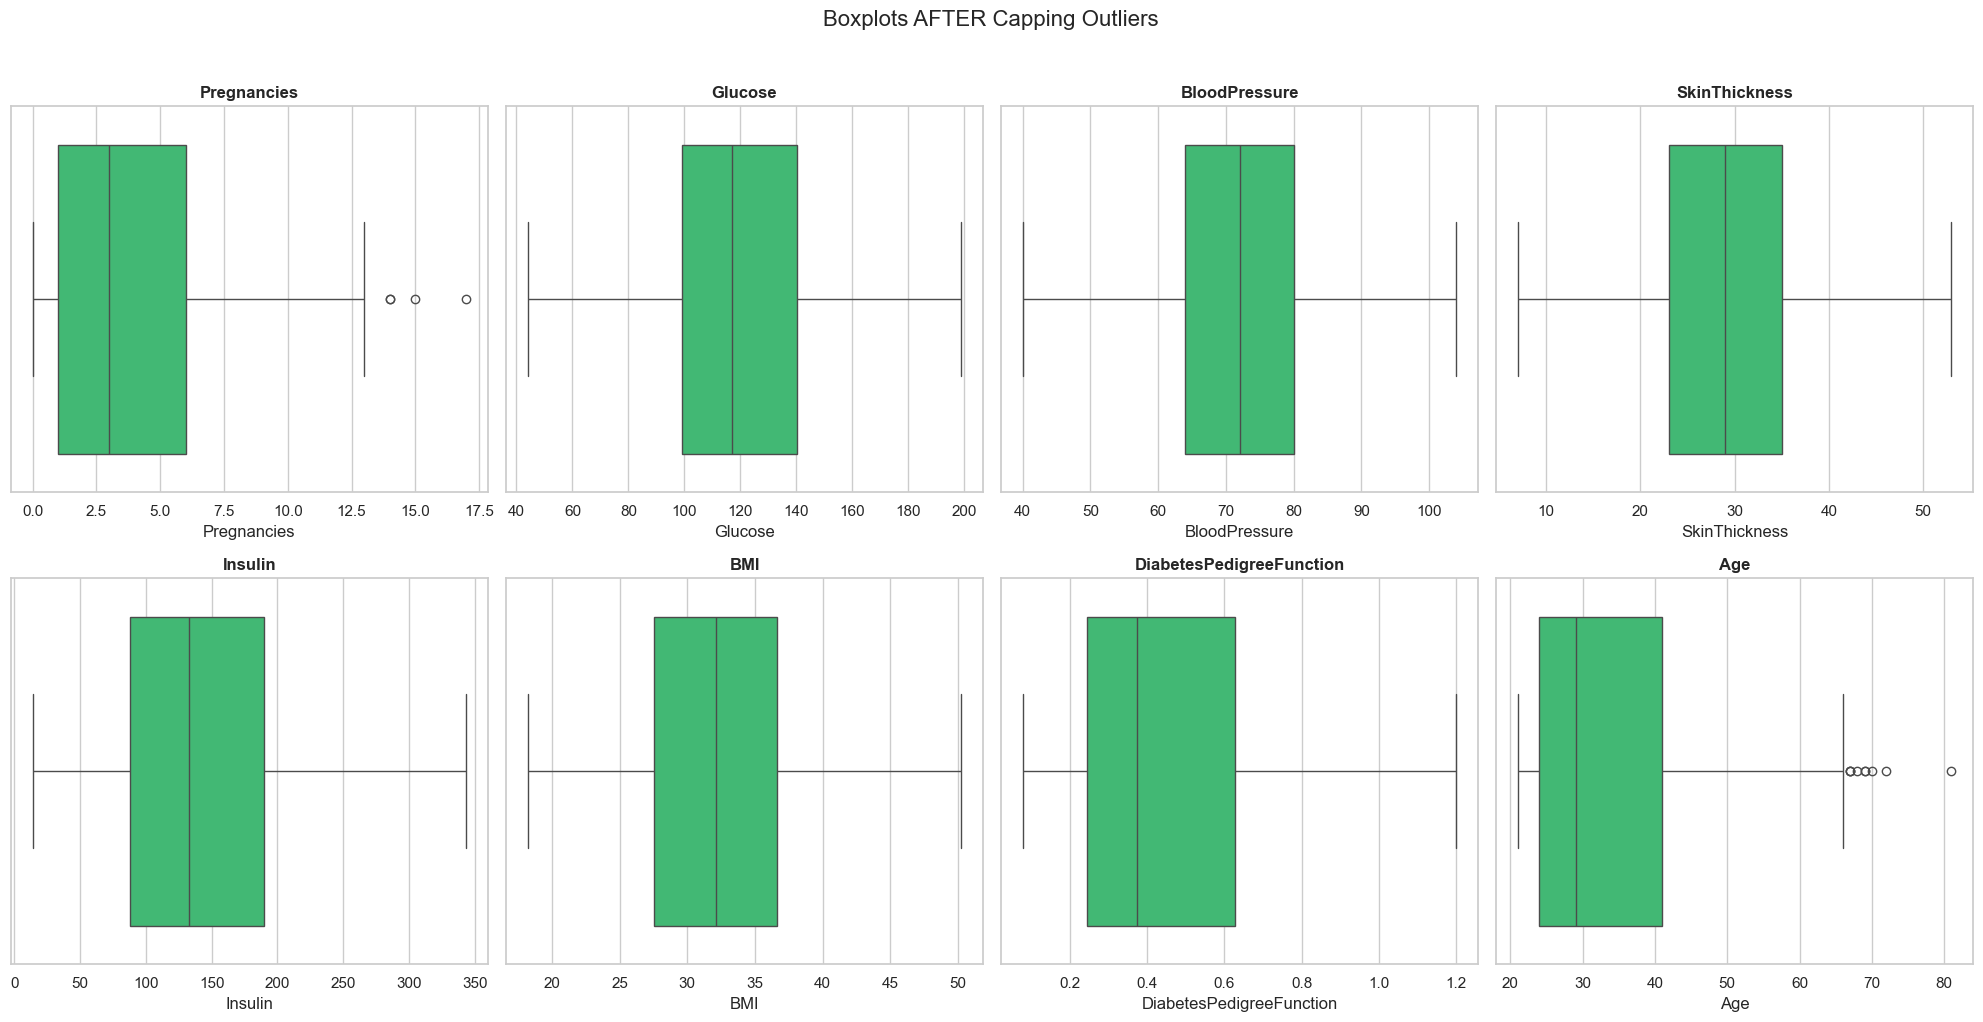

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.598177,72.354687,29.015885,147.518132,32.363073,0.458914,33.240885
std,3.369578,30.496543,11.811034,9.032175,78.885826,6.678217,0.285596,11.760232
min,0.000000,44.000000,40.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.000000,64.000000,23.000000,87.900000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,132.900000,32.090000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,35.000000,190.150000,36.600000,0.626250,41.000000
max,17.000000,199.000000,104.000000,53.000000,343.525000,50.250000,1.200000,81.000000


In [9]:
# capping
df_capped = cap_outliers_iqr(df_imputed, OUTLIER_COLUMNS)

# fix result values
df_capped["Pregnancies"] = df_capped["Pregnancies"].round().astype(int)
df_capped["Age"] = df_capped["Age"].round().astype(int)

# visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(CLINICAL_FEATURES):
    sns.boxplot(x=df_capped[col], ax=axes[i], color="#2ecc71")
    axes[i].set_title(col, fontweight="bold")

plt.suptitle("Boxplots AFTER Capping Outliers", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "preprocessing_boxplots_after_capping.png", dpi=150, bbox_inches="tight")
plt.show()

display(df_capped.describe())

## Feature Variability & Relationships


Feature Variances (Desc):
Insulin                     6222.97
Glucose                      930.04
BloodPressure                139.50
Age                          138.30
SkinThickness                 81.58
BMI                           44.60
Pregnancies                   11.35
DiabetesPedigreeFunction       0.08
dtype: float64


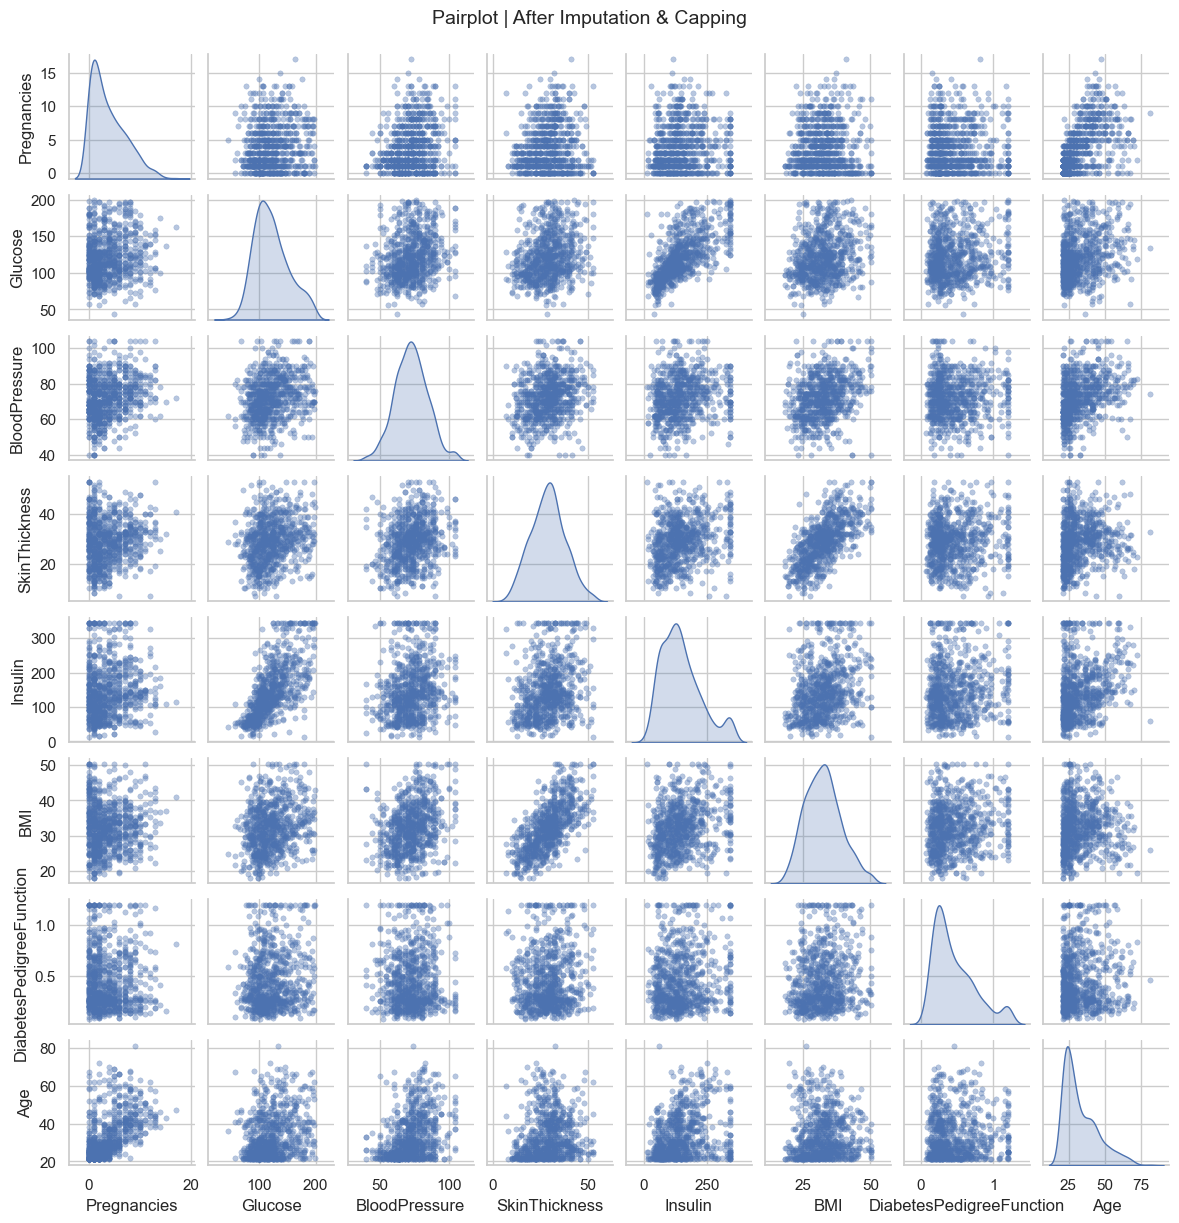

In [14]:
variances = df_capped.var().sort_values(ascending=False)
print("Feature Variances (Desc):")
print(variances.round(2))

sns.pairplot(
    df_capped,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15, "edgecolor": None},
    height=1.5
)
plt.suptitle("Pairplot | After Imputation & Capping", y=1.02, fontsize=14)
# plt.savefig(FIGURES_DIR / "preprocessing_pairplot_full.png", dpi=150, bbox_inches="tight")
plt.show()

## Scaling / Standardization
K-Means uses Euclidean distance, so features must be on the same scale. 
We use `StandardScaler` (mean=0, std=1) as it handles skewed distributions better than MinMax.

In [17]:
df_scaled,scaled = scale_data(df_capped,CLINICAL_FEATURES,"standard")
save_artifact(scaled,MODELS_DIR / "standard_scaler.joblib")

print("Data Scaled Successfully -) Mean = 0, std = 1")

display(df_scaled.describe().round(2))

df_scaled.to_csv(PROCESSED_DATA_DIR / "dataset_preprocessed.csv", index=False)

print("Process saved at dataset_preprocessed")


Data Scaled Successfully -) Mean = 0, std = 1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.14,-2.55,-2.74,-2.44,-1.69,-2.12,-1.33,-1.04
25%,-0.84,-0.74,-0.71,-0.67,-0.76,-0.73,-0.75,-0.79
50%,-0.25,-0.15,-0.03,-0.00,-0.19,-0.04,-0.30,-0.36
75%,0.64,0.61,0.65,0.66,0.54,0.63,0.59,0.66
max,3.91,2.54,2.68,2.66,2.49,2.68,2.60,4.06


Process saved at dataset_preprocessed
